# End to end ML Project

Cuando estas trabajando un proyecto de Machine Learning, despues de haber preparado toda la data para los analisis que vayas a hacer, tienes que realizar un trabajo de paneo general de que haras:

1. Ver a que tipo de desafio me estoy enfrentando:

- Supervisado o No Supervisado?
- Online Learning o Batch Learning?
- Aprendizaje por refuerzo?
- Cuales algoritmos usare?

Tienes que realizarte todas estas preguntas para ver como lo enfrentaras

2. Seleccionar metrica de rendimiento:

Tienes que ver cual metrica de rendimiento o **performance** usaras ya que dependiendo de como hayas pensado el paso **(1)** asi mismo tendras que elegir una metrica u otra que iremos viendo en el curso, Por ejemplo, para Regresion **(Supervisado)** solemos usar 2:

La mas comunmente usada es:
- RMSE(Root Mean Squared Error):
$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

Pero cuando trabajamos con datos que tienen muchos outliers o datos **atipicos** como por ejemplo casas fuera de lo normal, pues ahi usaremos mejor la siguiente:
- MAE(Mean Absolute Error):
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$


Y ya pronto veremos otras metricas dependiendo del problema de ML que nos enfrentemos y diferentes pasos


---
# Project Workfow

Para nuestro proyecto usaremos el dataset de **California Housing Prices**.

El dataset contiene información sobre distritos (o grupos de manzanas) en California. Cada fila representa un distrito.

### EDA

Lo primero que hay que hacer es explorar los datos:

In [41]:
import pandas as pd

housing = pd.read_csv("data/housing.csv")
housing.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [42]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


Vemos como de 20640 instancias hay 20433 que son no nulos en el total de dormitorios lo cual habra que arreglarlo de alguna forma

Ademas vemos que hay variable categorica la cual es OCEAN PROXIMITY por lo que seria ideal revisarla

In [43]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

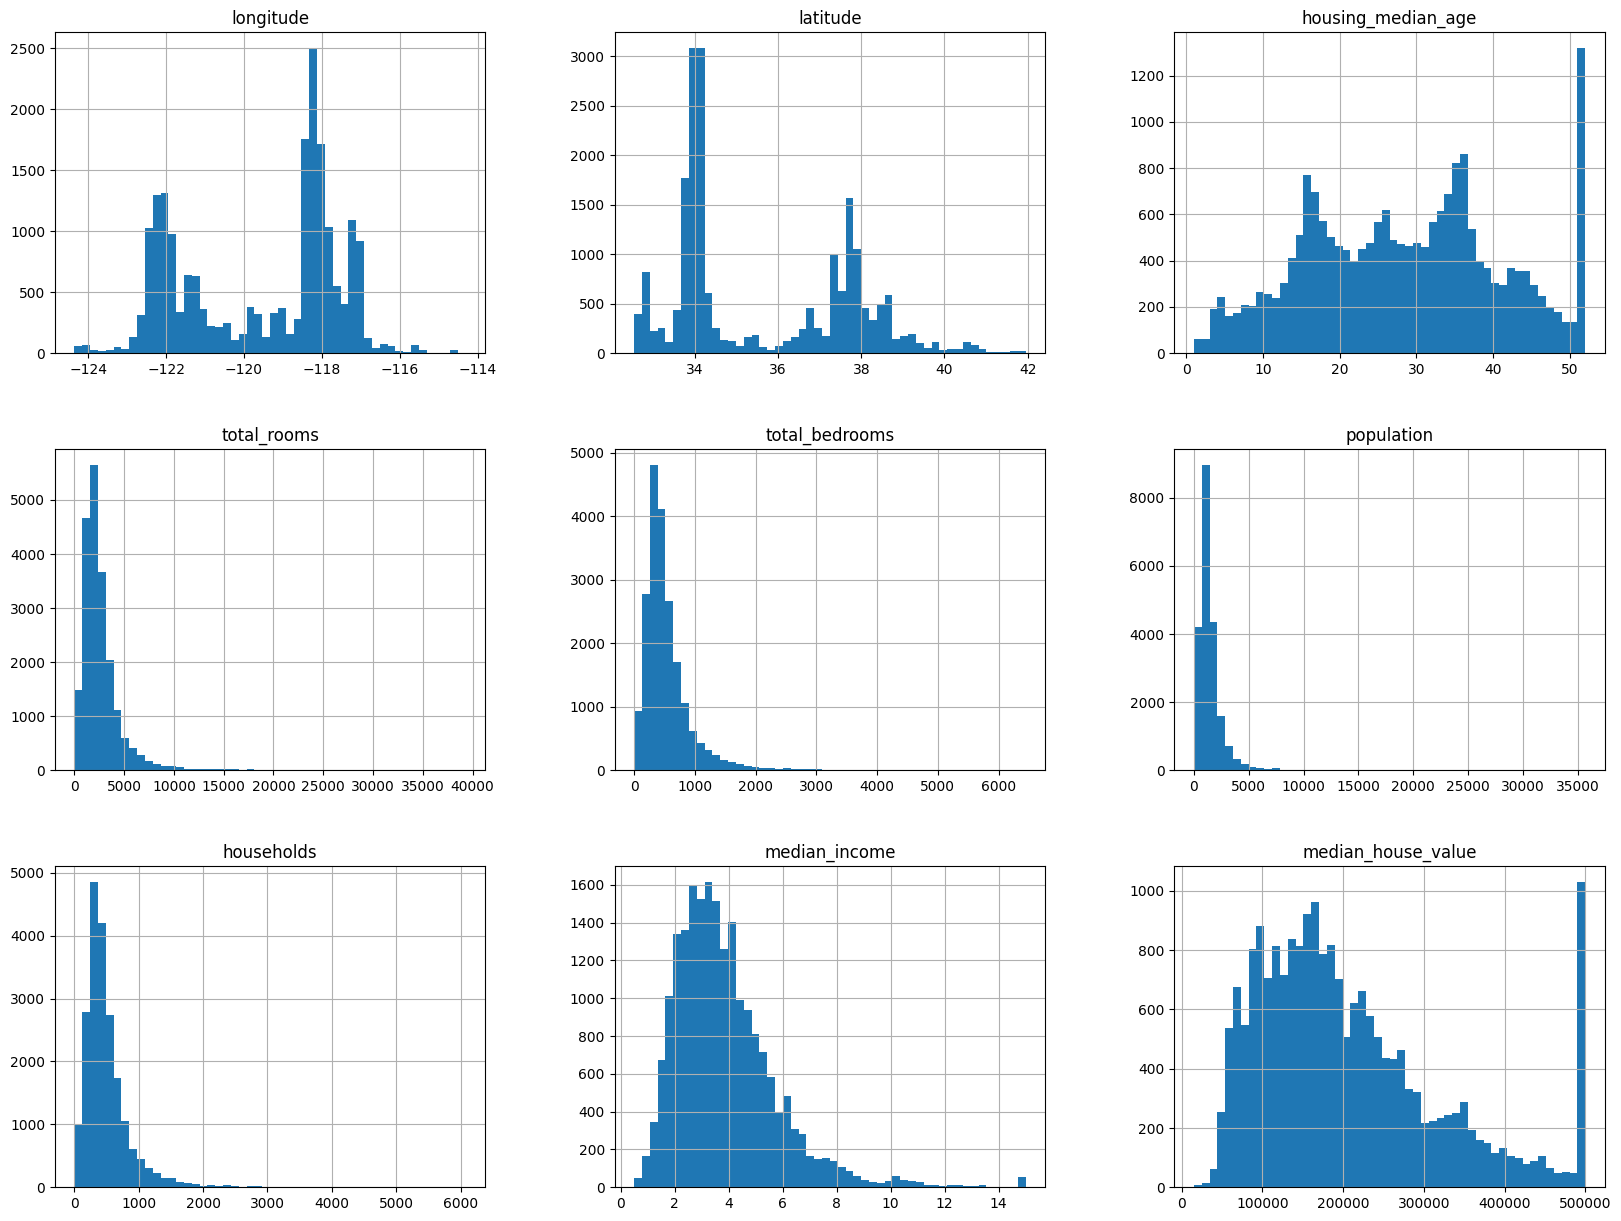

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

housing.hist(bins=50,figsize=(20,15))
plt.show()

Lo que podemos ver de las distribuciones y graficos, vemos que hay columnas fueron **capped** o **limitadas** a un valor o fueron **escaladas** ya que vemos como en $median-income$ estan como en miles y demas...

### Data Split

Otro paso muy importante que debemos hacer es dividir nuestro dataset en 3 partes:

- **Train set:** Es el conjunto más grande (típicamente 70-80%). Aquí es donde el modelo "estudia". El algoritmo ajusta sus parámetros (como los coeficientes en una Regresión Lineal) para minimizar el error en estos datos

- **Test set:** Este conjunto se guarda bajo llave y solo se toca una vez, al final de todo el proceso. Representa datos que el modelo nunca ha visto. Su función es darte una estimación realista de cómo se comportará el modelo en producción (ej. prediciendo precios reales en Cartagena)

- **Validation set:** Se usa mientras estás construyendo el modelo. Sirve para por ejemplo, Comparar diferentes algoritmos (¿Regresión Lineal o Árbol de Decisión?). Ajustar hiperparámetros (configuraciones que tú eliges, no el modelo). Detectar si el modelo se está sobreajustando antes de terminar

Si usas los mismos datos para entrenar y para probar, estarías haciendo trampa. Es como si el profesor te diera las respuestas del examen antes de que lo hagas:

Tu **RMSE y MAE** saldrán casi en cero (parecerá perfecto).

Pero cuando le des datos nuevos, el modelo fallará por completo porque no aprendió a generalizar, solo a recordar

Aunque tambien se suele usar el Validation Set, ahora usaremos por definicion del libro solo el **train y test** ya que se usará despues el **validation** 

Ademas en este caso usaremos una funcion implementada por Sickit-Learn que es una eleccion aleatoria que hace el dataset

In [45]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

Aunque despues veremos que no en todos los casos podemos aplicar esta, habran casos donde esto no será lo ideal sobre todo cuando tenemos que estratificar. Por ejemplo si de 1.000 Personas cojemos personas aleatoriamente no siempre será lo mejor nosotros queremos cojer un numero n de personas que sea representativo para toda la poblacion, es decir, si de esas 1000 51% son hombres y 49% mujeres queremos mantener ese ratio aun haciendo un muestreo mas pequeño de esa poblacion, esto se llama: **muestreo estratificado** ya que si esto no se incluye puede darnos un analisis con **bias** o **sesgado**

### Data visualization

Siempre vamos a querer ver insights de los datos o visualizaciones para esto podemos hacer muchas relaciones por ejemplo en la latitud y longitud:

<Axes: xlabel='longitude', ylabel='latitude'>

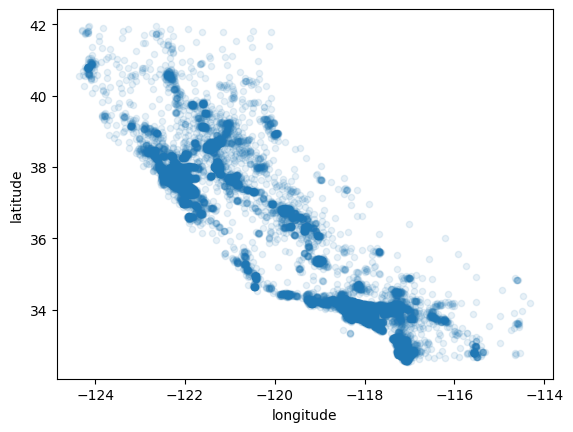

In [46]:
housing.plot(kind="scatter",x="longitude",y="latitude",alpha=0.1)

Aqui podemos ver que hay lugares con patrones de muy alta densidad, ademas siempre vamos a querer ver mas cosas con las demas variables como el precio, por lo que haremos lo siguiente:

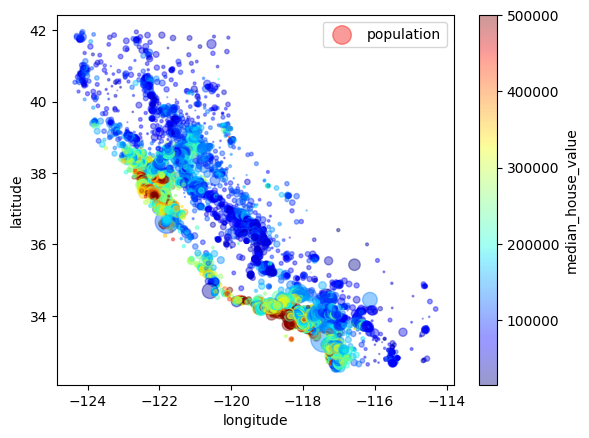

In [47]:
housing.plot(kind="scatter",x="longitude",y="latitude",alpha=0.4,
             s=housing["population"]/100, label="population",
             c="median_house_value",cmap=plt.get_cmap("jet"),
             colorbar=True)
plt.legend()
plt.show()

Esto lo que nos dice es que los precios de la casas estan mucho mas relacionados a otras caracteristicas como la poblacion que hay cercana, si esta cerca de el agua y demas cosas

### Miremos las correlaciones

In [48]:
housing_without_ocean_prox = housing.drop(columns="ocean_proximity")
corr_matrix = housing_without_ocean_prox.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

Como vemos una de las variables con las que mas correlacionada esta el valor de las casas es el **ingreso medio** veamos un scatter plot a ver que tal se ve:

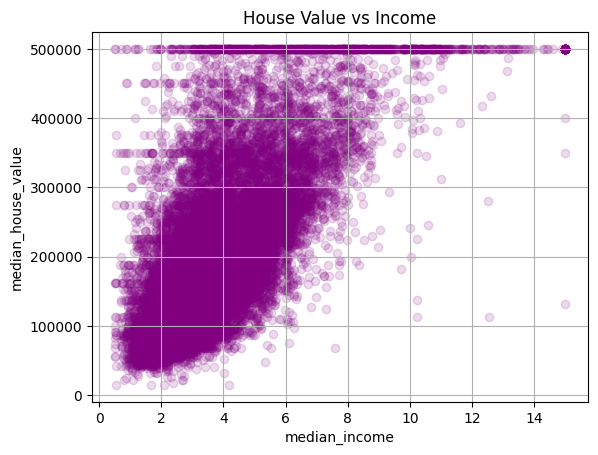

In [49]:
plt.scatter(x=housing["median_income"],y=housing["median_house_value"],color="purple",alpha=0.15)
plt.title("House Value vs Income")
plt.grid(True)
plt.xlabel("median_income")
plt.ylabel("median_house_value")
plt.show()

Vemos que hay una correlacion fuerte, por el alta tendencia alcista, asi como vimos antes, los precios estan **capped** a 500.000$ y ademas vemos otras lineas horizontales sutiles en 450.000 mas o menos, 350.000 y cerca de 280.000

Nosotros claramente no queremos que los algoritmos reproduzan estos **data quirks** o **anomalias**

### Experimentando con las features

Ademas vemos como algunas features no son tan buenas y podriamos sacar algunas de **combinaciones** de 2 features, por ejemplo, si tienes el numero de casas que hay un distrito esto no será muy util, lo que si será util es saber cuantas habitaciones o dormitorios hay por casa, similarmente el numero de dormitorias por si solo no es muy util, lo que quieres es compararlo con el numero de habitaciones

In [50]:
housing["habitaciones_por_casa"] = housing["total_rooms"]/housing["households"]
housing["dormitorios_por_habitacion"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["poblacion_por_casa"] = housing["population"]/housing["households"]

In [51]:
housing_without_ocean_prox = housing.drop(columns="ocean_proximity")
corr_matrix = housing_without_ocean_prox.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value            1.000000
median_income                 0.688075
habitaciones_por_casa         0.151948
total_rooms                   0.134153
housing_median_age            0.105623
households                    0.065843
total_bedrooms                0.049686
poblacion_por_casa           -0.023737
population                   -0.024650
longitude                    -0.045967
latitude                     -0.144160
dormitorios_por_habitacion   -0.255880
Name: median_house_value, dtype: float64

Como vemos algunas de las nuevas estan mucho mas correlacionadas, por ejemplo, **dormitorios_por_habitacion** y **habitaciones_por_casa**

### Preparemos los datos para Algoritmos de **Machine Learning**

Lo que ahora haremos será crear algunas funciones utiles, para nuestro proyecto de limpieza y separaremos las features **predictoras** de las **labels**

In [52]:
import numpy as np

housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

In [53]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [54]:
housing = strat_train_set.drop("median_house_value", axis=1) # drop labels for training set
housing_labels = strat_train_set["median_house_value"].copy()

La mayoria de los Algoritmos de Machine Learning no pueden funcionar con datos faltantes por lo que nos encargaremos de ello, para eso hay funciones de **Sickit-learn** que nos ayudan, nosotros en este caso imputaremos con la mediana:

In [55]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

Para que esto funcione solo debemos tener **Features numericas** por lo que ocean proximity hay que sacarla

In [56]:
housing_num = housing.drop("ocean_proximity",axis=1)

In [57]:
X = imputer.fit_transform(housing_num)
X

array([[-121.46      ,   38.52      ,   29.        , ...,    0.20578363,
           3.16855524,    2.        ],
       [-117.23      ,   33.09      ,    7.        , ...,    0.16071429,
           2.62369792,    5.        ],
       [-119.04      ,   35.37      ,   44.        , ...,    0.19159456,
           2.22333333,    2.        ],
       ...,
       [-122.72      ,   38.44      ,   48.        , ...,    0.23479491,
           2.6627907 ,    3.        ],
       [-122.7       ,   38.31      ,   14.        , ...,    0.18383518,
           2.41117764,    3.        ],
       [-122.14      ,   39.97      ,   27.        , ...,    0.20574606,
           3.17258883,    3.        ]], shape=(16512, 12))

El resultado en un array de numpy con las **Features Transformadas** por lo que hay que convertirlo de  nuevo en un Dataframe de Pandas

In [58]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)
housing_tr.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   16512 non-null  float64
 1   latitude                    16512 non-null  float64
 2   housing_median_age          16512 non-null  float64
 3   total_rooms                 16512 non-null  float64
 4   total_bedrooms              16512 non-null  float64
 5   population                  16512 non-null  float64
 6   households                  16512 non-null  float64
 7   median_income               16512 non-null  float64
 8   habitaciones_por_casa       16512 non-null  float64
 9   dormitorios_por_habitacion  16512 non-null  float64
 10  poblacion_por_casa          16512 non-null  float64
 11  income_cat                  16512 non-null  float64
dtypes: float64(12)
memory usage: 1.6 MB


### Manejando texto features **categoricas**

Como habiamos visto antes, recordamos que habia una feature categorica la cual era **ocean_proximity** 

In [59]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.value_counts()

ocean_proximity
<1H OCEAN          7277
INLAND             5262
NEAR OCEAN         2124
NEAR BAY           1847
ISLAND                2
Name: count, dtype: int64

Como vemos no es una entrada arbitraria categorica, si no que es una especio de **enum** o de **categorias** para esto se suele usar el OrdinalEncoder de Scikit-learn

In [60]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_enc = OrdinalEncoder()

In [61]:
housing_cat_encoded = ordinal_enc.fit_transform(housing_cat)
ordinal_enc.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

Lo unico mal de este **encoder** es que generalmente los algoritmos de ML toman entre mas grande el numero o como mejor o mas bueno cosa que no interesaria si realmente fuera ordinal nuestra categoria (malo,normal,bueno) peor en este caso no lo es asi que lo ideal enrealidad sería utilizar **One-hot Encoder**

In [62]:
from sklearn.preprocessing import OneHotEncoder

onehot_enc = OneHotEncoder()

In [63]:
housing_cat_1hot = onehot_enc.fit_transform(housing_cat)
housing_cat_1hot, onehot_enc.categories_

(<Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 16512 stored elements and shape (16512, 5)>,
 [array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
        dtype=object)])

In [64]:
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]], shape=(16512, 5))

### Feature **Scaling**

Una de las transformaciones mas importantes que debes aplicar a tu dataset es **escalamiento**. Los Algoritmos de ML no funcionan bien cuando las variables numericas tienen diferentes escalas.

Hay 2 formas diferentes de tratar con esto:
- Min-Max Scaling o Normalizacion: Esta técnica escala todos los valores a un rango específico, usualmente entre 0 y 1. Es muy sensible a los valores atípicos (outliers). Se hace con **MinMaxScaler**
$$X_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

- Standardization o Estandarizacion: A diferencia de la normalización, esta técnica no limita los valores a un rango específico, sino que centra los datos para que tengan una media ($\mu$) de 0 y una desviación estándar ($\sigma$) de 1. Es mucho más robusta frente a los outliers. Se usa **StandardScaler**

$$z = \frac{x - \mu}{\sigma}$$

### Pipelines de Transformacion

Como vemos hay muchas transformaciones que antes hay que hacerle a los datos por lo que Scikit-learn nos da una clase **pipeline** que nos ayuda a hacer Secuencias de Transformaciones

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Nota: Si no tienes una clase para "attribs_adder", podemos quitarla por ahora
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    # ("attribs_adder", CombinedAttributesAdder()), # Solo si definiste la clase del libro
    ("std_scaler", StandardScaler())
])

# Aplicamos el pipeline solo a las columnas numéricas
housing_num = housing.drop(columns="ocean_proximity")
housing_num_prepared = num_pipeline.fit_transform(housing_num)

In [66]:
from sklearn.compose import ColumnTransformer

num_features = list(housing_num)
cat_features = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat",OneHotEncoder(), cat_features)
])

In [67]:
housing_prepared = full_pipeline.fit_transform(housing)
housing_prepared

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ...,  0.        ,
         0.        ,  0.        ],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.        ,
         0.        ,  0.        ],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.        ,
         0.        ,  0.        ]], shape=(16512, 17))

### Seleccionar y Entrenar un Modelo

Una vez hemos visto todo el **frame** del problema y hemos aplicado transformaciones y preparacion de los datos, ahora tenemos que seleccionar el algoritmo que usaremos, para este dataset usaremos Regresion para predecir, el median_house_value.

In [68]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared,housing_labels)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)

predictions = lin_reg.predict(some_data_prepared)
predictions

array([ 81207.67117047, 316596.26559522, 142015.72645295, 185414.09044777,
       234487.57732276])

In [70]:
some_labels

12655     72100.0
15502    279600.0
2908      82700.0
14053    112500.0
20496    238300.0
Name: median_house_value, dtype: float64

Ahora veamos como fue el performance del modelo con la metrica que elegimos al inicio el RMSE o el MAE

In [71]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_mae = mean_absolute_error(housing_labels,housing_predictions)
lin_rmse = np.sqrt(lin_mse)
print(f"RMSE: {lin_rmse} & MAE: {lin_mae}")

RMSE: 67795.89725607877 & MAE: 49133.70285770558


Como vemos esta un poco mal ya que teniendo en cuenta que la mayoria de las casas estan entre 150k y 250k-300k un error de casi 70k USD no es algo que sirva mucho por lo que cuando es asi es quizas mejor elegir otro modelo de prediccion como puede ser un Decision Tree que es capaz de interpretar relaciones no lineales

In [72]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared,housing_labels)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [73]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_rmse = np.sqrt(mean_squared_error(housing_labels, housing_predictions))
tree_mae = mean_absolute_error(housing_labels,housing_predictions)
print(f"RMSE: {tree_rmse} & MAE: {tree_mae}")

RMSE: 0.0 & MAE: 0.0


Que?! no puede darnos 0 de ERROR esto lo que probablemente nos esta diciendo es que el modelo esta **Overfitting** es decir literalmente memorizó todo pero no va a ser bueno haciendo generalizaciones o predicciones

Hay 2 formas principales de lidiar con esto:

1. train_test_split(): Es decir dividir el dataset en train,test y probar
2. Cross-Validation

### Cross-Validation

Una gran alternativa es usar la validacion cruzada lo cual hace que se divida el dataset de training en k sub-conjuntos diferentes llamados **folds** y luego entrena y evalua el modelo 10 veces y da las 10 puntuaciones o scores de entrenamientos de vuelta 

In [74]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
                         scoring="neg_mean_squared_error",
                         cv=10)

tree_rmse_scores = np.sqrt(-scores)
tree_rmse_scores

array([72989.79801953, 69902.30346231, 68377.76826941, 71985.34412664,
       69971.95928838, 75875.30611037, 72489.56372376, 71221.38313842,
       69437.34397032, 71441.82191484])

In [75]:
print(f"Vemos como el Decision Tree tiene una media de {tree_rmse_scores.mean():.2f} lo cual es bastante error para ser el Decision Tree")

Vemos como el Decision Tree tiene una media de 71369.26 lo cual es bastante error para ser el Decision Tree


Vemos como el Decision Tree esta en Overfitting con los datos

In [76]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                         scoring="neg_mean_squared_error",
                         cv=10)
lin_rmse_scores = np.sqrt(-scores)
lin_rmse_scores

array([70868.70847958, 63732.15501022, 67406.84729475, 68054.46205429,
       66057.44209764, 71772.87705405, 69552.32971357, 68136.58168677,
       65406.99394321, 69735.67915511])

In [77]:
print(f"Vemos como con la regresion y cross validation da el error menos que el decision tree, dando la regresion con {lin_rmse_scores.mean():.2f} de error en promedio")

Vemos como con la regresion y cross validation da el error menos que el decision tree, dando la regresion con 68072.41 de error en promedio


Otro approach de modelos que podemos seguir es el de los **Ensemble Models** pero estos los veremos mas fondo despues, sin embargo, ahora veremos uno en concreto no mas para hacer el experimento y es el de Random Forest el cual es basicamente poner a trabajar varios arboles de decision que veremos despues, no mas para probar

In [78]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared,housing_labels)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Despues de entrenarlo ahora veremos su rendimiento aplicandole tambien Cross-Validation

In [79]:
from sklearn.model_selection import cross_val_score
score = cross_val_score(forest_reg, housing_prepared,
                        housing_labels,scoring="neg_mean_squared_error",
                         cv=10)

forest_rmse = np.sqrt(-scores)
print(f"El RMSE promedio en los 10 folds es: {forest_rmse.mean():.2f}")

El RMSE promedio en los 10 folds es: 68072.41


Lo cual claramente es mucho menor a los otros 2 modelos, sin embargo, no quita que probablemente se siga haciendo overfitting

Usualmente cuando trabajamos con modelos de ML queremos volver a usar facilmente un modelo con los hiperparametros ya puestos, para esto se usa la libreria **joblib** asi:

'''
import joblib

joblib.dump(my_model, "my_model")
...

my_model_loaded = joblib.load("my_model.pkl)
'''

### Finetune del modelo

Hay varias formas de Finetunear los modelos:

#### GridSearch

Una de ellas es **GridSearchCV** en la cual lo que se hace es que tu le dices scikit-learn con cuales hiperparametros del modelo quieres probar y el automaticamente lo hace por ti.

Es un método de optimización de hiperparámetros que realiza una búsqueda exhaustiva a través de un subconjunto especificado manualmente del espacio de hiperparámetros de un algoritmo de aprendizaje. En esencia, el proceso define una "rejilla" de combinaciones posibles; para cada punto de esta rejilla, el modelo se entrena y evalúa —generalmente mediante Validación Cruzada (K-Fold Cross-Validation)— para medir su rendimiento. El objetivo principal es automatizar la selección de la configuración óptima que minimice una función de pérdida (como el MSE en regresión) o maximice una métrica de desempeño ($R^2$, Accuracy), garantizando que la elección de los parámetros no sea arbitraria, sino basada en la capacidad predictiva del modelo sobre datos no observados.

In [80]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"n_estimators":[3,10,30]},
    {"max_features":[2,4,6,8]},
    {"bootstrap":[False]},
    {"n_estimators":[3,10]},
    {"max_features":[2,3,4]}
]

forest_reg = RandomForestRegressor()

gridsearch = GridSearchCV(forest_reg, param_grid,cv=5,
                          scoring="neg_mean_squared_error",
                          return_train_score=True)

gridsearch.fit(housing_prepared, housing_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'n_estimators': [3, 10, ...]}, {'max_features': [2, 4, ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

Tu puedes obtener del GridSeach cual fue la combinacion de hiperparametros que mejor desempeño tuvo e incluso todas las demas asi:

In [81]:
gridsearch.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",8
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [82]:
cvres = gridsearch.cv_results_
for mean_score,params in zip(cvres["mean_test_score"],cvres["params"]):
    print(np.sqrt(-mean_score),params)

59939.02475015071 {'n_estimators': 3}
53194.52367866656 {'n_estimators': 10}
51249.34950058689 {'n_estimators': 30}
52193.072594452606 {'max_features': 2}
50332.34993192312 {'max_features': 4}
50173.25151732875 {'max_features': 6}
50085.75986660035 {'max_features': 8}
67719.93228669107 {'bootstrap': False}
59616.30704263948 {'n_estimators': 3}
53098.60024259812 {'n_estimators': 10}
52219.20124671335 {'max_features': 2}
51000.02659637869 {'max_features': 3}
50483.743848504986 {'max_features': 4}


# Ejercicios Finales

1. Implementa un Support Vector Machine Regressor a ver que tal te va, con un kernel lineal y aplicale Randomized Search

Primero sin RandomizedSearch

In [83]:
from sklearn.svm import SVR
svr = SVR(kernel="linear",C=1.0, epsilon=0.1)
svr.fit(housing_prepared,housing_labels)

from sklearn.model_selection import cross_val_score
scores = cross_val_score(svr, housing_prepared,
                        housing_labels,scoring="neg_mean_squared_error",
                         cv=10)

svr_rmse = np.sqrt(-scores)
print(f"El RMSE promedio en los 10 folds es: {svr_rmse.mean():.2f}")

El RMSE promedio en los 10 folds es: 107840.51


Ahora con RandomizedSearch

In [84]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import reciprocal, uniform

param_distributions = {
    'kernel': ['linear', 'rbf'],
    'C': reciprocal(0.1, 100),
    'epsilon': uniform(0.01, 0.2),
    'gamma': ['scale', 'auto']  # Solo afecta al kernel RBF
}

rnd_search = RandomizedSearchCV(
    SVR(), 
    param_distributions=param_distributions, 
    n_iter=20, 
    cv=5, 
    scoring='neg_mean_squared_error', 
    verbose=2, 
    random_state=42,
    n_jobs=-1 # Usa todos los núcleos de tu procesador
)

rnd_search.fit(housing_prepared, housing_labels)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END C=6.2513735745217485, epsilon=0.0412037280884873, gamma=scale, kernel=linear; total time=  22.9s
[CV] END C=6.2513735745217485, epsilon=0.0412037280884873, gamma=scale, kernel=linear; total time=  24.7s
[CV] END C=1.3292918943162166, epsilon=0.20014286128198325, gamma=scale, kernel=rbf; total time=  25.1s
[CV] END C=6.2513735745217485, epsilon=0.0412037280884873, gamma=scale, kernel=linear; total time=  22.6s
[CV] END C=1.3292918943162166, epsilon=0.20014286128198325, gamma=scale, kernel=rbf; total time=  26.3s
[CV] END C=6.2513735745217485, epsilon=0.0412037280884873, gamma=scale, kernel=linear; total time=  25.6s
[CV] END C=1.3292918943162166, epsilon=0.20014286128198325, gamma=scale, kernel=rbf; total time=  26.1s
[CV] END C=1.3292918943162166, epsilon=0.20014286128198325, gamma=scale, kernel=rbf; total time=  26.0s
[CV] END C=1.3292918943162166, epsilon=0.20014286128198325, gamma=scale, kernel=rbf; total time=  

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': <scipy.stats....x718fed7f8f50>, 'epsilon': <scipy.stats....x718fe53393a0>, 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... v

In [86]:
# Obtener el mejor modelo y sus parámetros
print(f"Mejores parámetros: {rnd_search.best_params_}")

# Calcular el RMSE final del mejor modelo
best_rmse = np.sqrt(-rnd_search.best_score_)
print(f"Mejor RMSE obtenido en CV: {best_rmse:.4f}")

Mejores parámetros: {'C': np.float64(6.2513735745217485), 'epsilon': np.float64(0.0412037280884873), 'gamma': 'scale', 'kernel': 'linear'}
Mejor RMSE obtenido en CV: 86701.5152
